In [1]:
import requests
import os
from dotenv import load_dotenv
from datetime import date

load_dotenv()
API_KEY = os.getenv("NASA_API_KEY")

url = "https://api.nasa.gov/DONKI/FLR"
params = {
    "startDate": "2025-04-01",
    "endDate": "2025-05-03",
    "api_key": API_KEY
}

response = requests.get(url, params=params)
data = response.json()

if not data:
    print("太陽フレアの記録は見つかりませんでした。")
else:
    for event in data[:3]:  # 最初の3件だけ表示
        print("📅 開始時刻:", event["beginTime"])
        print("🔚 終了時刻:", event["endTime"])
        print("🌞 クラス:", event.get("classType", "不明"))
        print("📍 リージョン番号:", event.get("activeRegionNum", "不明"))
        print("📝 ソース:", event.get("sourceLocation", "不明"))
        print("-" * 40)


📅 開始時刻: 2025-04-01T06:37Z
🔚 終了時刻: 2025-04-01T06:53Z
🌞 クラス: M5.6
📍 リージョン番号: 14046
📝 ソース: N03E29
----------------------------------------
📅 開始時刻: 2025-04-01T22:18Z
🔚 終了時刻: 2025-04-01T22:41Z
🌞 クラス: M2.5
📍 リージョン番号: 14048
📝 ソース: S18E46
----------------------------------------
📅 開始時刻: 2025-04-04T14:34Z
🔚 終了時刻: 2025-04-04T14:53Z
🌞 クラス: C4.4
📍 リージョン番号: 14052
📝 ソース: S23W28
----------------------------------------


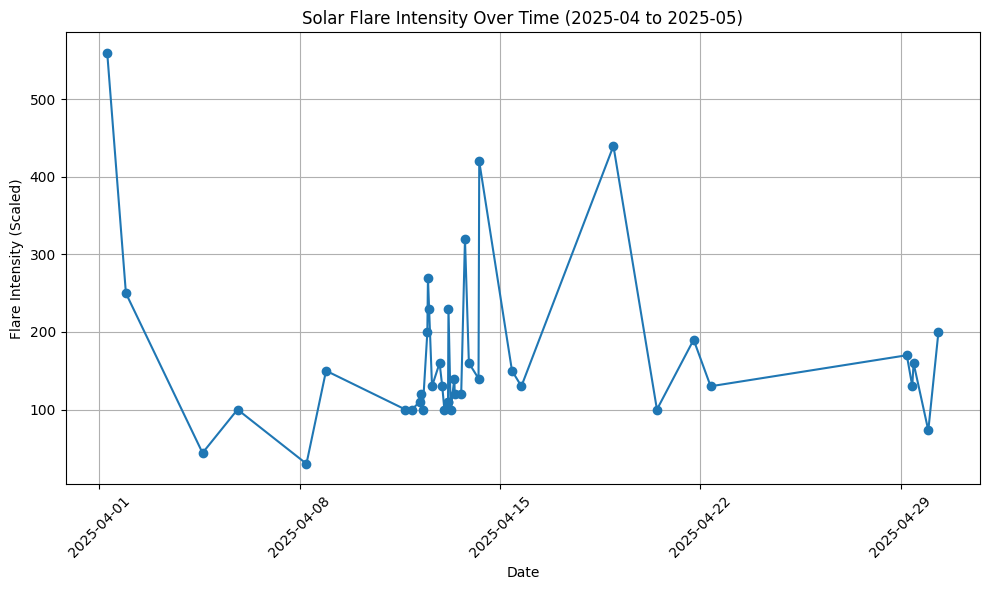

In [4]:
from datetime import datetime
import matplotlib.pyplot as plt
from matplotlib.dates import DateFormatter
import matplotlib.dates as mdates
# データ整形
flare_dates = []
flare_classes = []

# フレアクラスを数値化（A=0.1, B=1, C=10, M=100, X=1000）
def convert_class_to_value(class_type):
    if not class_type:
        return None
    scale = {"A": 0.1, "B": 1, "C": 10, "M": 100, "X": 1000}
    letter = class_type[0]
    number = float(class_type[1:])
    return scale.get(letter, 0) * number

for event in data:
    date_str = event.get("beginTime")
    class_type = event.get("classType")
    value = convert_class_to_value(class_type)
    if date_str and value:
        dt = datetime.fromisoformat(date_str)
        flare_dates.append(dt)
        flare_classes.append(value)

# グラフ描画
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(flare_dates, flare_classes, marker='o', linestyle='-')
ax.set_title("Solar Flare Intensity Over Time (2025-04 to 2025-05)")
ax.set_xlabel("Date")
ax.set_ylabel("Flare Intensity (Scaled)")
ax.xaxis.set_major_formatter(DateFormatter('%Y-%m-%d'))
ax.xaxis.set_major_locator(mdates.WeekdayLocator(interval=1))
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()